# Introduction to Matplotlib with Spatial Data

Welcome to your introduction to **Matplotlib**, the foundational plotting library in Python. In this notebook you will learn how to create, customize, and save a wide variety of plots — all using **real spatial datasets**.

We will work with two datasets throughout this notebook:

1. **USGS Earthquake Data** — A CSV feed of recent earthquakes recorded worldwide, including latitude, longitude, magnitude, and depth.
2. **IBTrACS Hurricane Data** — Historical tropical cyclone track observations from 2022 in the Western Hemisphere, including wind speed, pressure, and geographic coordinates.

### Learning Objectives

By the end of this notebook you will be able to:

- Import and configure Matplotlib for use in a Jupyter environment.
- Create line plots, scatter plots, bar charts, and histograms using both the **pyplot** interface and the **object‑oriented** interface.
- Plot data directly from **pandas DataFrames**.
- Build multi‑panel figures with **subplots**.
- Customize titles, labels, legends, colormaps, and axis limits.
- Save publication‑ready figures to disk.

Let's get started!

## Importing Libraries

Every Python data‑visualization workflow begins with importing the necessary libraries. Here we bring in three packages:

- **NumPy** (`np`) — the core numerical computing library. Matplotlib is built on top of NumPy arrays, so you will see it used throughout this notebook for generating and manipulating data.
- **pandas** (`pd`) — a powerful data‑analysis library that lets us load CSVs, filter rows, compute statistics, and plot directly from DataFrames.
- **Matplotlib** (`plt`) — the plotting library itself. We import `matplotlib.pyplot`, which provides a MATLAB‑like plotting interface that is the most common way to interact with Matplotlib.

Run the cell below to import all three.

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Downloading Spatial Datasets

Before we can visualize anything, we need data. In spatial analysis it is common to pull data from live feeds or web services and then save a local copy so that your analysis is reproducible even if the remote source changes.

### Earthquake Data

The **U.S. Geological Survey (USGS)** publishes a real‑time CSV feed of all earthquakes recorded in the past 30 days. Each row represents a single seismic event and includes fields such as:

| Column | Description |
|---|---|
| `time` | UTC timestamp of the event |
| `latitude` / `longitude` | Geographic coordinates of the epicenter |
| `depth` | Depth of the event in kilometers below the surface |
| `mag` | Magnitude on the Richter scale |
| `place` | Human‑readable description of the location |

### Hurricane Data

The **International Best Track Archive for Climate Stewardship (IBTrACS)** is the most complete global dataset of tropical cyclones. We query a feature service hosted by NOAA/Esri for 2022 storms in the Western Hemisphere. Key columns include:

| Column | Description |
|---|---|
| `NAME` | Storm name (e.g., *Ian*, *Fiona*) |
| `LAT` / `LON` | Geographic coordinates of the observation |
| `USA_WIND` | Maximum sustained wind speed (knots) |
| `USA_PRES` | Minimum central pressure (millibars) |
| `year`, `month`, `day` | Date components of the observation |

The cell below downloads both datasets and saves them as local CSV files. **You only need to run this cell once** — all later cells load from the saved files.

In [119]:
# Download earthquake data from USGS (last 30 days)
earthquake_url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"
eq = pd.read_csv(earthquake_url)
eq.to_csv("earthquakes.csv", index=False)

# Download hurricane data from IBTrACS via ArcGIS Feature Service (2022 Western Hemisphere storms)
import geopandas as gpd

hurricane_service_url = (
    "https://services2.arcgis.com/FiaPA4ga0iQKduv3/ArcGIS/rest/services/"
    "IBTrACS_ALL_list_v04r00_lines_1/FeatureServer/0/query?"
    "where=OBJECTID+%3E+0+AND+year%3D2022+AND+LON%3C0+AND+LAT%3E0"
    "&outFields=*&returnGeometry=true&f=pgeojson"
)

hurricane_gdf = gpd.read_file(hurricane_service_url)
hur = pd.DataFrame(hurricane_gdf, copy=True)
hur.to_csv("hurricanes.csv", index=False)

print("Datasets downloaded and saved locally.")
print(f"  Earthquakes : {len(eq):,} rows")
print(f"  Hurricanes  : {len(hur):,} rows")

Datasets downloaded and saved locally.
  Earthquakes : 9,622 rows
  Hurricanes  : 1,939 rows


## Exploring the Earthquake Data

Whenever you receive a new dataset, the first step should always be **exploration**. Before you start plotting, you need to know what columns are available, what data types they contain, and whether there are any missing values.

The pandas methods we will use most often for exploration are:

- **`.head()`** — shows the first five rows of the DataFrame so you can preview the data.
- **`.info()`** — prints column names, non‑null counts, and data types — very useful for spotting columns that need type conversion.
- **`.describe()`** — gives summary statistics (mean, min, max, standard deviation, etc.) for every numeric column.

Take a moment to look at the output of the cell below and identify which columns we will use for plotting.

In [120]:
# Load the saved earthquake data
eq = pd.read_csv("earthquakes.csv")
eq.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-26T04:24:59.410Z,38.823666,-122.765663,2.1500,1.00,md,16,121,0.007563,0.01,...,2026-02-26T04:26:36.495Z,"4 km W of Cobb, CA",earthquake,0.27,0.410000,0.11,17.0,automatic,nc,nc
1,2026-02-26T04:22:52.820Z,38.910332,-123.250336,4.7700,1.79,md,16,96,0.048570,0.05,...,2026-02-26T04:24:26.634Z,"15 km SE of Boonville, CA",earthquake,0.29,0.550000,0.15,14.0,automatic,nc,nc
2,2026-02-26T04:17:28.718Z,32.086000,-102.028000,4.3081,1.30,ml,40,49,0.100000,0.50,...,2026-02-26T04:29:28.341Z,"10 km NNE of Midland, Texas",earthquake,0.00,0.864171,0.20,23.0,automatic,tx,tx
3,2026-02-26T03:59:50.190Z,38.822498,-122.811501,2.5800,1.04,md,20,52,0.018390,0.02,...,2026-02-26T04:42:20.888Z,"7 km NW of The Geysers, CA",earthquake,0.25,0.430000,0.22,21.0,automatic,nc,nc
4,2026-02-26T03:59:04.300Z,38.821167,-122.813164,3.8800,0.83,md,8,82,0.017190,0.01,...,2026-02-26T04:17:21.655Z,"7 km NW of The Geysers, CA",earthquake,0.61,2.770000,0.28,8.0,automatic,nc,nc


In [121]:
# Quick summary of columns, types, and missing values
eq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9622 entries, 0 to 9621
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             9622 non-null   object 
 1   latitude         9622 non-null   float64
 2   longitude        9622 non-null   float64
 3   depth            9622 non-null   float64
 4   mag              9621 non-null   float64
 5   magType          9621 non-null   object 
 6   nst              9622 non-null   int64  
 7   gap              9622 non-null   int64  
 8   dmin             9608 non-null   float64
 9   rms              9622 non-null   float64
 10  net              9622 non-null   object 
 11  id               9622 non-null   object 
 12  updated          9622 non-null   object 
 13  place            9622 non-null   object 
 14  type             9622 non-null   object 
 15  horizontalError  9130 non-null   float64
 16  depthError       9546 non-null   float64
 17  magError      

In [122]:
# Statistical summary of numeric columns
eq.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,9622.000000,9622.000000,9622.000000,9621.000000,9622.000000,9622.000000,9608.000000,9622.000000,9130.000000,9546.000000,9586.000000,9619.000000
mean,39.993634,-112.262044,20.978610,1.710672,26.533153,106.399501,0.435907,0.314048,2.692386,2.743778,0.191170,17.785113
std,17.562387,65.302396,50.150067,1.207335,22.949688,66.268455,1.384829,0.302777,4.706689,5.204193,0.119467,26.035979
min,-67.468600,-179.958100,-3.480000,-1.540000,0.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.233958,-149.775750,3.650000,0.950000,12.000000,59.000000,0.025145,0.100000,0.290000,0.530000,0.103075,7.000000
50%,38.794416,-122.720833,7.470000,1.600000,20.000000,84.000000,0.098615,0.180000,0.658369,1.049413,0.177000,12.000000
75%,55.409000,-110.874083,14.000000,2.100000,33.000000,138.000000,0.300000,0.500000,3.800000,2.766375,0.237514,19.000000
max,69.505000,179.961900,654.627000,7.100000,295.000000,358.000000,33.227000,2.200000,124.600000,115.700000,2.100000,562.000000


## Exploring the Hurricane Data

Let's do the same exploration for the hurricane dataset. Notice that this dataset has a different structure — each row is a **track segment observation** for a named storm, not a discrete event. That means a single hurricane (like *Ian*) will have many rows, one for each time the storm was observed.

Understanding this structure is critical: when we later want to plot the wind speed *over time* for a single storm, we will need to **filter** the DataFrame to just one storm name.

In [123]:
# Load the saved hurricane data
hur = pd.read_csv("hurricanes.csv")
hur.head()

,OBJECTID,SID,BASIN,SUBBASIN,NAME,NATURE,year,month,day,Hurricane_Date,LAT,LON,USA_WIND,USA_PRES,geometry
0,688160,2022148N13263,EP,MM,Agatha,DS,2022,5,27,1653710400000,12.9,-97.3,25,1008,"LINESTRING (-97.3000488280573 12.899999618655,..."
1,688161,2022148N13263,EP,MM,Agatha,DS,2022,5,27,1653710400000,12.8,-97.5,28,1007,LINESTRING (-97.4999999996032 12.8000001904575...
2,688162,2022148N13263,EP,MM,Agatha,TS,2022,5,28,1653796800000,12.8,-97.7,30,1006,LINESTRING (-97.6999511720473 12.8000001904575...
3,688163,2022148N13263,EP,MM,Agatha,TS,2022,5,28,1653796800000,12.8,-97.8,33,1005,LINESTRING (-97.8000488280876 12.8000001904575...
4,688164,2022148N13263,EP,MM,Agatha,TS,2022,5,28,1653796800000,12.9,-97.9,35,1004,"LINESTRING (-97.9000244138605 12.899999618655,..."


In [124]:
# How many unique storms are in the dataset?
print(f"Unique storm names: {hur['NAME'].nunique()}")
print(hur['NAME'].unique())

Unique storm names: 32
['Agatha' 'Alex' 'Blas' 'Celia' 'Bonnie' 'Colin' 'Darby' 'Estelle' 'Frank'
 'Georgette' 'Howard' 'Ivette' 'Unnamed' 'Javier' 'Danielle' 'Earl' 'Kay'
 'Madeline' 'Fiona' 'Lester' 'Gaston' 'Newton' 'Ian' 'Hermine' 'Orlene'
 'Paine' 'Julia' 'Karl' 'Roslyn' 'Lisa' 'Martin' 'Nicole']


## Quick Plots with the pyplot Interface

Matplotlib gives you **two ways** to create plots:

1. **The pyplot interface** (`plt.plot()`, `plt.scatter()`, etc.) — fast and convenient for one‑off plots.
2. **The object‑oriented interface** (`fig, ax = plt.subplots()`) — more flexible and recommended for complex or multi‑panel figures.

In this section we will use the **pyplot interface** to quickly create four of the most common plot types using our spatial datasets. Later in the notebook we will switch to the object‑oriented approach and explore customization in depth.

The four plot types we will cover are:

| Plot Type | Best For | Spatial Example |
|---|---|---|
| **Line plot** | Trends over time | Hurricane wind speed over time |
| **Scatter plot** | Relationships between two variables | Earthquake locations colored by magnitude |
| **Histogram** | Distribution of a single variable | Frequency of earthquake magnitudes |
| **Bar chart** | Comparing categories | Number of storms per month |

### Line Plot — Hurricane Wind Speed Over Time

A **line plot** connects data points in order and is ideal for showing how a quantity changes over time. In the spatial sciences, you might use a line plot to show how a hurricane's wind speed intensifies (or weakens) throughout its lifespan, how river discharge changes over a flood event, or how temperature varies across a transect.

Below, we filter the hurricane dataset to a single storm and plot its maximum sustained wind speed (`USA_WIND`) against a datetime constructed from the `year`, `month`, and `day` columns.

> **Note:** `pd.to_datetime()` can accept a DataFrame with columns named `year`, `month`, and `day` and will automatically combine them into proper datetime objects.

Plotting wind speed for: Agatha


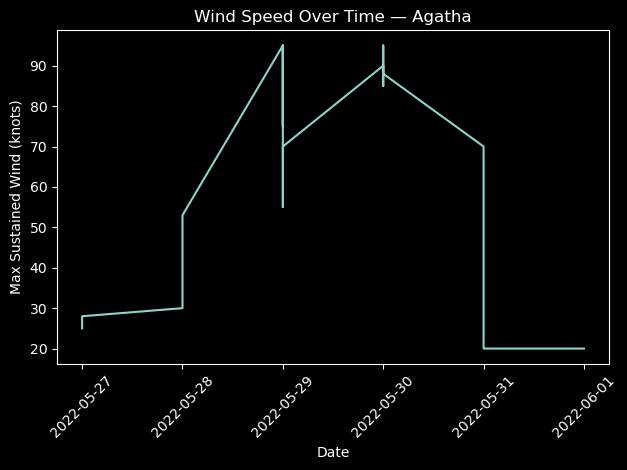

In [125]:
# Convert time columns and filter to one storm
hur_dt = hur.copy()
hur_dt['date'] = pd.to_datetime(hur_dt[['year', 'month', 'day']])

# Pick the first named storm as our example
storm_name = hur_dt['NAME'].iloc[0]
storm = hur_dt[hur_dt['NAME'] == storm_name].sort_values('date')

print(f"Plotting wind speed for: {storm_name}")

plt.figure()
plt.plot(storm['date'], storm['USA_WIND'])
plt.xlabel("Date")
plt.ylabel("Max Sustained Wind (knots)")
plt.title(f"Wind Speed Over Time — {storm_name}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Scatter Plot — Earthquake Locations Colored by Magnitude

A **scatter plot** places individual data points on a two‑dimensional plane and is perfect for exploring the relationship between two numeric variables. When we map `longitude` to the x‑axis and `latitude` to the y‑axis, we get a simple **spatial plot** that shows where earthquakes occurred.

We can add extra dimensions of information by:

- **Coloring** each dot by magnitude (`c=eq['mag']`) — this lets us see which areas experience stronger quakes.
- **Sizing** each dot by magnitude (`s=eq['mag']*5`) — larger dots draw the eye to the most significant events.
- **Setting transparency** (`alpha=0.5`) — so overlapping dots don't obscure each other.

The `plt.colorbar()` function adds a legend that maps colors to magnitude values.

C:\Users\georg\AppData\Local\ESRI\conda\envs\arcgispro-py3-dl\Lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


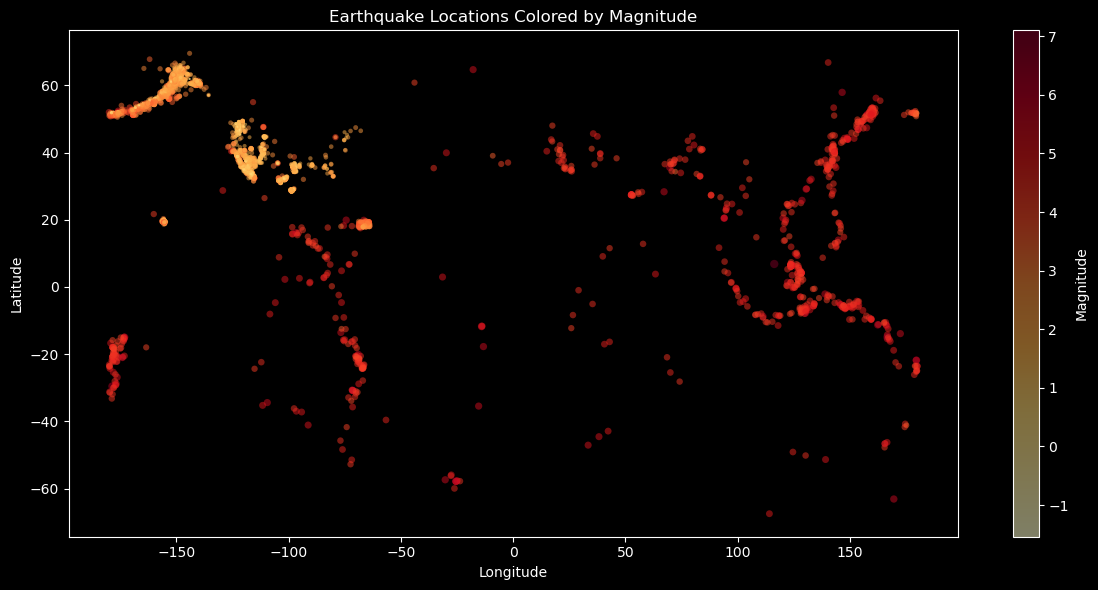

In [126]:
# Earthquake spatial scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(eq['longitude'], eq['latitude'],
            c=eq['mag'],
            s=eq['mag'] * 5,
            alpha=0.5,
            cmap='YlOrRd',
            edgecolors='none')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquake Locations Colored by Magnitude")
plt.colorbar(label="Magnitude")
plt.tight_layout()
plt.show()

### Histogram — Distribution of Earthquake Magnitudes

A **histogram** groups continuous data into bins and counts how many observations fall into each bin. This is essential for understanding the **distribution** (or spread) of your data.

For example, the histogram below will show us whether most earthquakes are small (low magnitude) or if the data is spread evenly across all magnitudes. In seismology, we know that small earthquakes vastly outnumber large ones — the histogram should confirm that pattern.

The `bins` parameter controls how many groups the data is divided into. Fewer bins give a coarser picture; more bins reveal finer detail but can also introduce noise. A value of 30 is a good starting point.

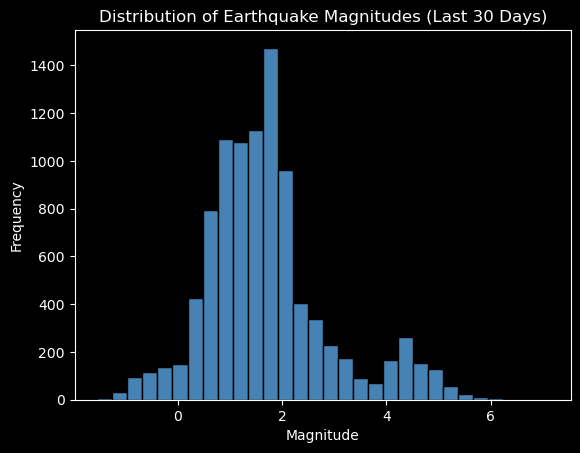

In [127]:
# Histogram of earthquake magnitudes
plt.figure()
plt.hist(eq['mag'].dropna(), bins=30, edgecolor='black', color='steelblue')
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.title("Distribution of Earthquake Magnitudes (Last 30 Days)")
plt.show()

### Bar Chart — Number of Storms Per Month

A **bar chart** is used to compare **categorical** data — data that falls into distinct groups rather than a continuous range. Each bar represents one category, and its height represents the value for that category.

Here we count how many unique storms (`SID`) occurred in each month of 2022. This is useful for visualizing **hurricane seasonality** — we expect to see the most storms during the peak months of August through October.

We use `groupby('month')` to group the data by month, then `nunique()` on the storm identifier column to count distinct storms.

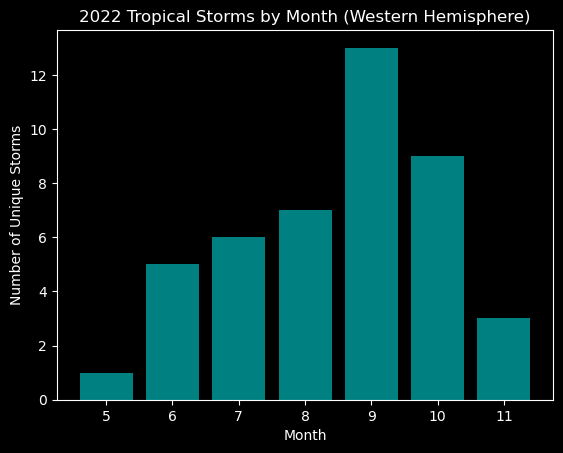

In [128]:
# Bar chart: unique storms per month in 2022
storms_per_month = hur.groupby('month')['SID'].nunique()

plt.figure()
plt.bar(storms_per_month.index.astype(str), storms_per_month.values, color='teal')
plt.xlabel("Month")
plt.ylabel("Number of Unique Storms")
plt.title("2022 Tropical Storms by Month (Western Hemisphere)")
plt.show()

### Quick Subplots — Comparing Distributions Side by Side

Often you will want to show two related plots next to each other so the reader can compare them. Matplotlib makes this easy with `plt.subplots()`, which creates a Figure containing multiple Axes (individual plots).

Below we place the earthquake magnitude distribution and the hurricane wind speed distribution side by side. Even though these are different phenomena measured in different units, comparing their distributions helps us notice similarities — both are right‑skewed, meaning there are many small values and few extreme ones.

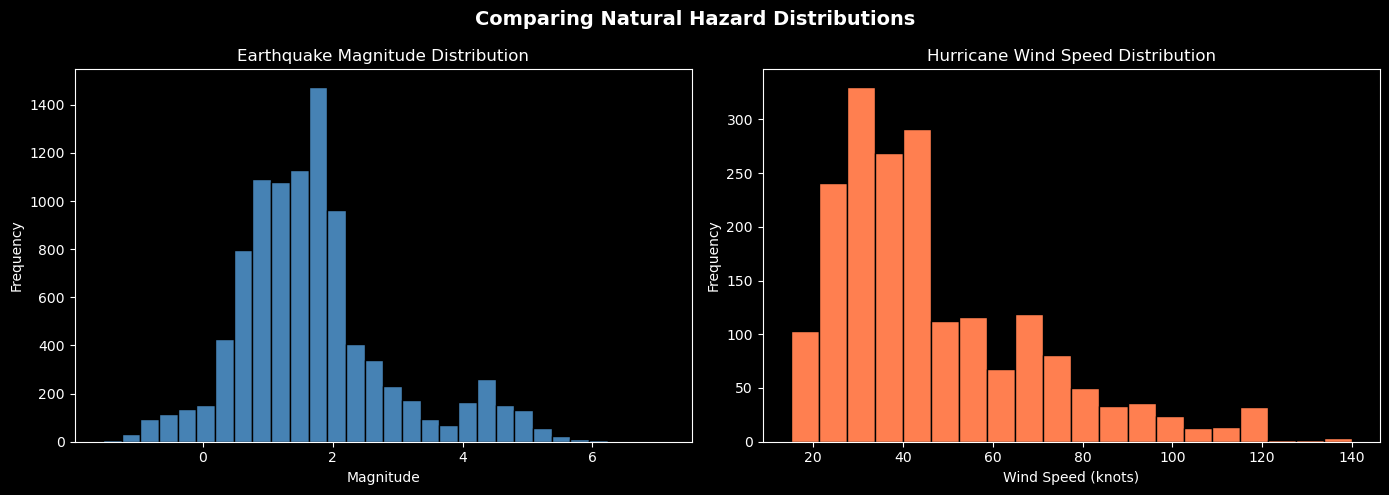

In [129]:
# Side-by-side histograms
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: Earthquake magnitudes
ax[0].hist(eq['mag'].dropna(), bins=30, color='steelblue', edgecolor='black')
ax[0].set_title("Earthquake Magnitude Distribution")
ax[0].set_xlabel("Magnitude")
ax[0].set_ylabel("Frequency")

# Right: Hurricane wind speeds
ax[1].hist(hur['USA_WIND'].dropna(), bins=20, color='coral', edgecolor='black')
ax[1].set_title("Hurricane Wind Speed Distribution")
ax[1].set_xlabel("Wind Speed (knots)")
ax[1].set_ylabel("Frequency")

fig.suptitle("Comparing Natural Hazard Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## The Object‑Oriented (OO) Interface

So far we have been using `plt.plot()`, `plt.scatter()`, etc. This is called the **pyplot** (or *stateful*) interface — Matplotlib keeps track of the "current" figure and axes behind the scenes.

The **object‑oriented** interface gives you explicit control over every piece of the plot by working with **Figure** and **Axes** objects directly:

```python
fig, ax = plt.subplots()   # create a Figure with one Axes
ax.plot(x, y)              # plot data on that Axes
```

This approach is preferred for any plot that requires more than basic customization, because you always know exactly which Axes you are modifying. It also scales naturally to multi‑panel figures.

Let's start with the basics.

### Key Terminology

Before we go further, let's define three terms that you will see everywhere in Matplotlib documentation:

- **Figure** (`fig`) — The entire canvas or window. Think of it as the blank piece of paper that holds everything. Created with `plt.figure()` or `plt.subplots()`.
- **Axes** (`ax`) — A single plot area within a Figure. One Figure can contain one or many Axes (e.g., a 2×2 grid of plots has four Axes). **This is not the same as "axis"!**
- **Axis** — A specific dimension of an Axes: the x‑axis (horizontal), y‑axis (vertical), or z‑axis (depth, for 3‑D plots).

The most common source of confusion for beginners is the difference between **Axes** (the plot) and **Axis** (the number line along one edge of the plot). Keep this distinction in mind as we continue.

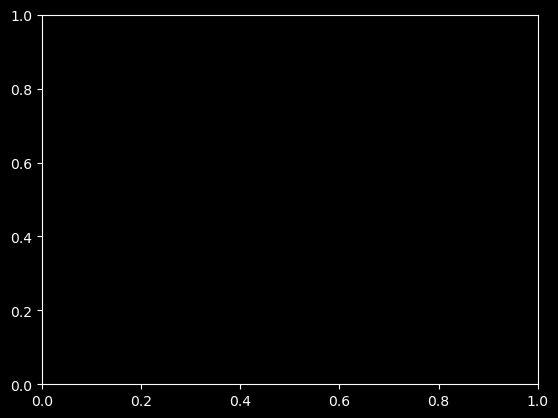

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


In [130]:
# Create an empty Figure with one Axes
fig, ax = plt.subplots()
plt.show()

# Let's verify the types
print(type(fig))  # matplotlib.figure.Figure
print(type(ax))   # matplotlib.axes._subplots.AxesSubplot

### A Standard Matplotlib Workflow

Regardless of whether you use the pyplot or OO interface, most Matplotlib visualizations follow the same general workflow:

| Step | Action | Example |
|---|---|---|
| 0 | **Import Matplotlib** | `import matplotlib.pyplot as plt` |
| 1 | **Prepare your data** | Load a CSV, filter rows, compute statistics |
| 2 | **Set up the plot** | `fig, ax = plt.subplots()` |
| 3 | **Plot data onto the Axes** | `ax.scatter(x, y)` |
| 4 | **Customize** | Titles, labels, colors, legends |
| 5 | **Save and/or show** | `fig.savefig('my_plot.png')` / `plt.show()` |

We will practice this workflow repeatedly throughout the rest of the notebook. Let's start with a quick example.

C:\Users\georg\AppData\Local\ESRI\conda\envs\arcgispro-py3-dl\Lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


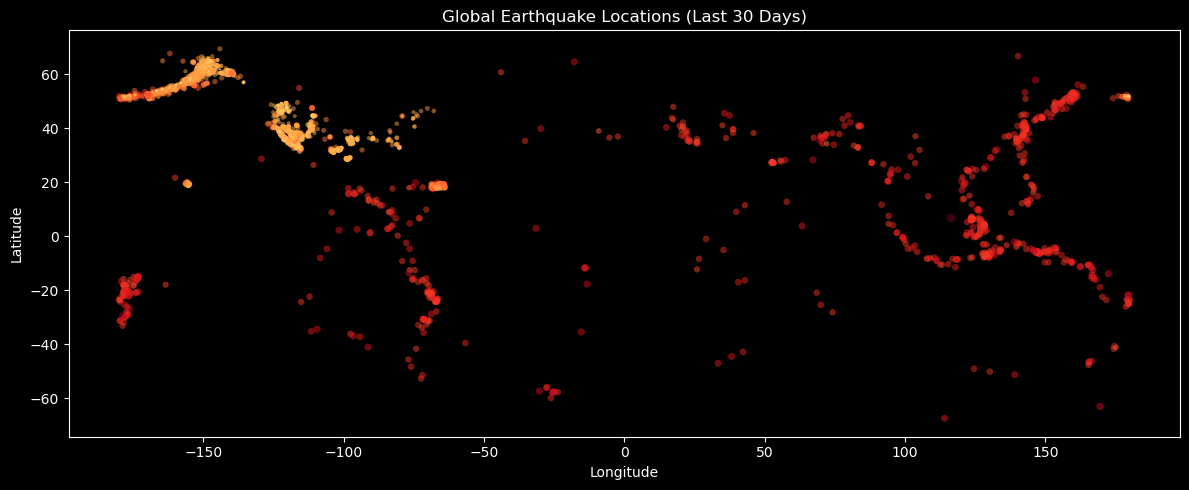

In [131]:
# Full workflow example with earthquake data

# 0. Import (already done above)

# 1. Prepare data — convert time column
eq['time'] = pd.to_datetime(eq['time'])
eq = eq.sort_values('time')

# 2. Set up the plot
fig, ax = plt.subplots(figsize=(12, 5))

# 3. Plot data
ax.scatter(eq['longitude'], eq['latitude'],
           c=eq['mag'], cmap='YlOrRd',
           s=eq['mag'] * 5, alpha=0.5, edgecolors='none')

# 4. Customize
ax.set_title("Global Earthquake Locations (Last 30 Days)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# 5. Show
plt.tight_layout()
plt.show()

## Making Common Plots with NumPy Arrays

Matplotlib visualizations are built on **NumPy arrays**. Even when you pass a pandas Series to a plot function, pandas converts it to a NumPy array behind the scenes.

In this section we will build the four main plot types using simple NumPy arrays so you understand the mechanics. Then in the next section we will switch to plotting directly from pandas DataFrames with real spatial data.

The four types are:

- **Line plot** — `ax.plot()` (the default)
- **Scatter plot** — `ax.scatter()`
- **Bar plot** — `ax.bar()` or `ax.barh()`
- **Histogram** — `ax.hist()`

We will also learn about `np.linspace()`, which generates evenly spaced numbers over a range and is very commonly used to create x‑axis data for smooth curves.

### Line Plot with NumPy

The **line plot** is Matplotlib's default visualization. If you call `ax.plot(x, y)`, it draws a line connecting each (x, y) pair in order.

Line plots are ideal for showing **trends over a continuous variable** — for example, how elevation changes along a transect, or how temperature varies throughout a day.

Below we use `np.linspace(0, 10, 100)` to create 100 evenly spaced x‑values between 0 and 10, then plot $y = x^2$ to produce a smooth parabola.

> **`np.linspace(start, stop, num)`** — Generates `num` evenly spaced values from `start` to `stop` (inclusive). This is different from `np.arange()`, which steps by a fixed increment. `linspace` is preferred when you want a specific *number* of points.

In [132]:
# Create an array of 100 evenly spaced values from 0 to 10
x = np.linspace(0, 10, 100)
x[:10]  # preview the first 10 values

array([0.        , 0.1010101 , 0.2020202 , 0.3030303 , 0.4040404 ,
       0.50505051, 0.60606061, 0.70707071, 0.80808081, 0.90909091])

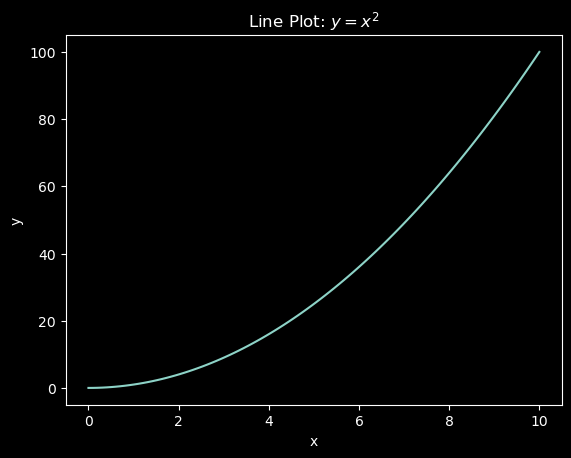

In [133]:
# Line plot: y = x^2
fig, ax = plt.subplots()
ax.plot(x, x**2)
ax.set_title("Line Plot: $y = x^2$")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

### Scatter Plot with NumPy

Scatter plots display individual data points **without connecting them**. They are ideal when you have many discrete observations and want to see the **relationship or clustering** between two variables.

In spatial analysis, scatter plots are used constantly — for instance, plotting longitude vs. latitude to see the spatial distribution of events.

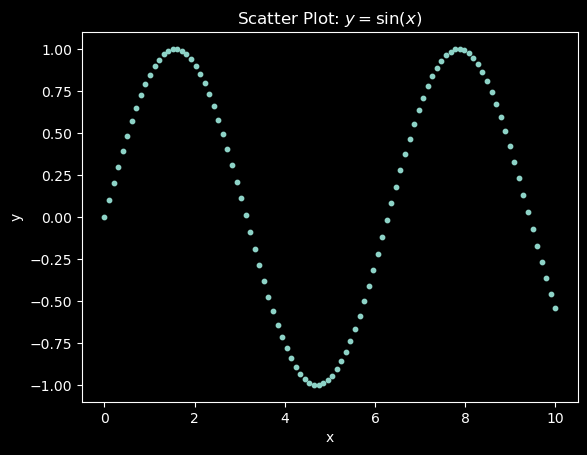

In [134]:
# Scatter plot: y = sin(x)
fig, ax = plt.subplots()
ax.scatter(x, np.sin(x), s=10)
ax.set_title("Scatter Plot: $y = \\sin(x)$")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

### Bar Plot with NumPy

Bar plots compare **categorical** quantities — items that belong to distinct groups. Each bar's height (or length, for horizontal bars) represents the value for that category.

In spatial contexts, you might use a bar plot to show the total area of each land‑cover class in a study region, the number of buildings per neighborhood, or the count of events per category.

You can create **vertical** bars with `ax.bar()` and **horizontal** bars with `ax.barh()`.

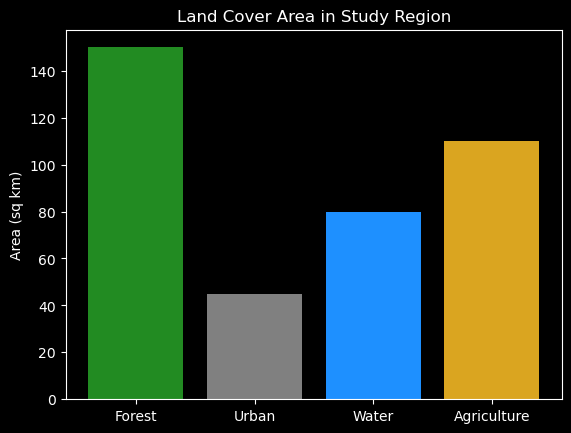

In [135]:
# Bar plot from a dictionary
land_cover_area = {"Forest": 150, "Urban": 45, "Water": 80, "Agriculture": 110}

fig, ax = plt.subplots()
ax.bar(land_cover_area.keys(), land_cover_area.values(), color=['forestgreen', 'gray', 'dodgerblue', 'goldenrod'])
ax.set_title("Land Cover Area in Study Region")
ax.set_ylabel("Area (sq km)")
plt.show()

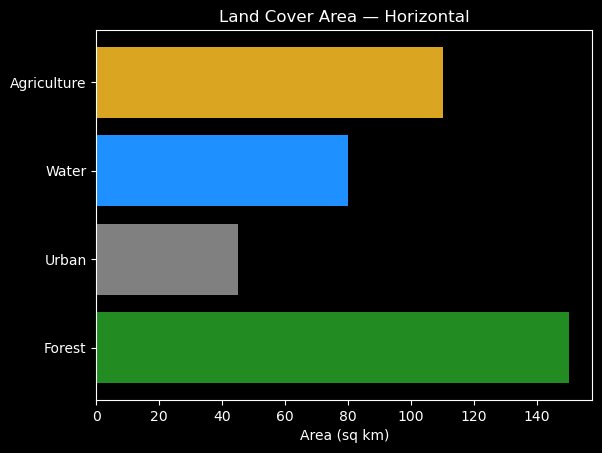

In [136]:
# Horizontal bar plot
fig, ax = plt.subplots()
ax.barh(list(land_cover_area.keys()), list(land_cover_area.values()),
        color=['forestgreen', 'gray', 'dodgerblue', 'goldenrod'])
ax.set_xlabel("Area (sq km)")
ax.set_title("Land Cover Area — Horizontal")
plt.show()

### Histogram with NumPy

A histogram groups a set of continuous values into **bins** and shows how many values fall into each bin. It answers the question: *"How is my data distributed?"*

Below we draw 1,000 random samples from a **normal (Gaussian) distribution** using `np.random.randn()`. You should see the classic bell‑curve shape.

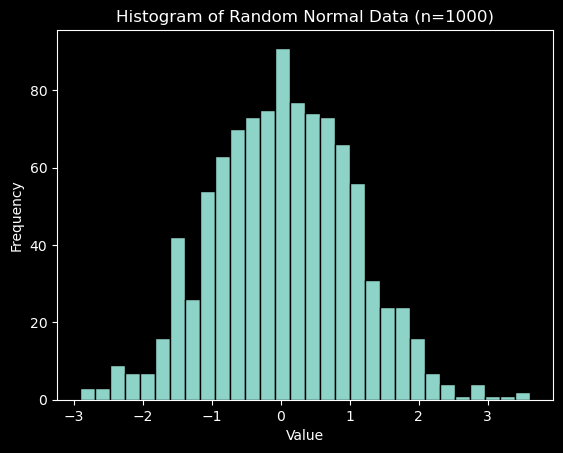

In [137]:
# Histogram of normally distributed data
random_data = np.random.randn(1000)

fig, ax = plt.subplots()
ax.hist(random_data, bins=30, edgecolor='black')
ax.set_title("Histogram of Random Normal Data (n=1000)")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
plt.show()

### Multi‑Panel Figures with Subplots

One of Matplotlib's most powerful features is the ability to place **multiple Axes** (plots) on a single Figure. This is done by passing `nrows` and `ncols` to `plt.subplots()`.

For example, `plt.subplots(nrows=2, ncols=2)` creates a 2×2 grid of four Axes. You can access each Axes by indexing into the returned array:

```python
fig, ax = plt.subplots(nrows=2, ncols=2)
ax[0, 0]  # top-left
ax[0, 1]  # top-right
ax[1, 0]  # bottom-left
ax[1, 1]  # bottom-right
```

Alternatively, you can **unpack** the Axes into individual variables for readability:

```python
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
```

Let's try both approaches.

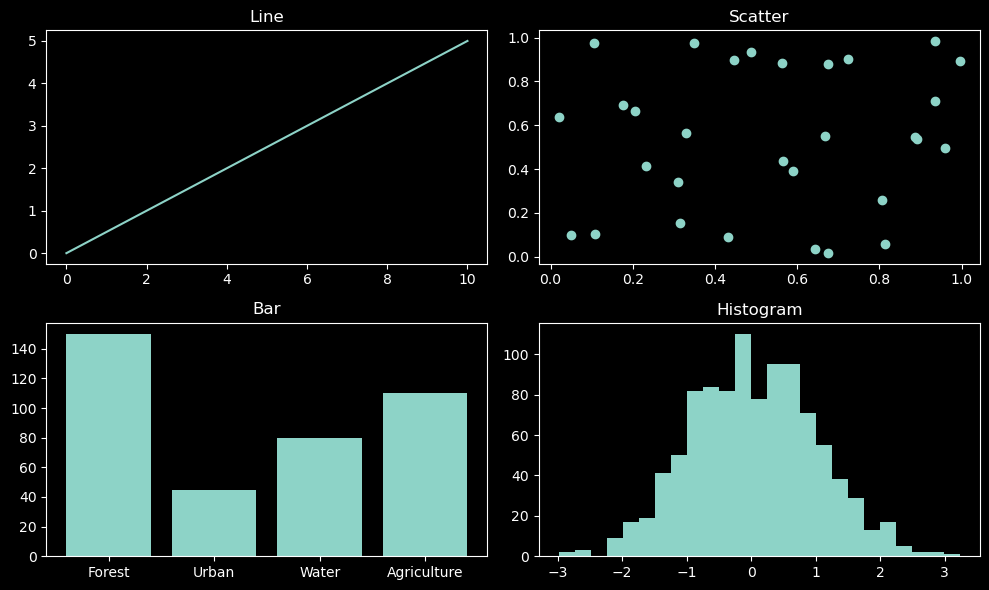

In [138]:
# Option 1: Named individual axes
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

ax1.plot(x, x / 2)
ax1.set_title("Line")

ax2.scatter(np.random.random(30), np.random.random(30))
ax2.set_title("Scatter")

ax3.bar(land_cover_area.keys(), land_cover_area.values())
ax3.set_title("Bar")

ax4.hist(np.random.randn(1000), bins=25)
ax4.set_title("Histogram")

plt.tight_layout()
plt.show()

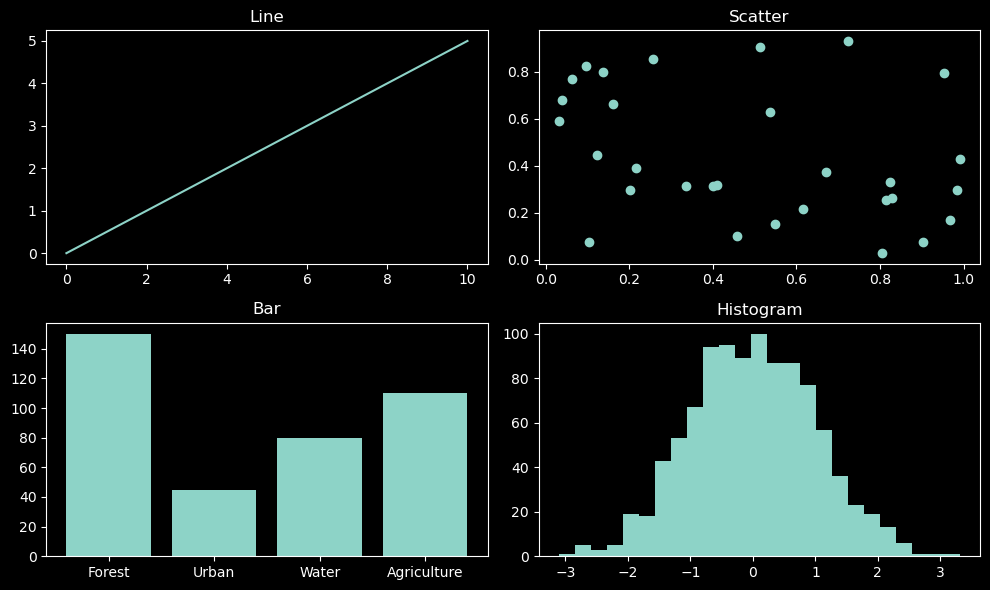

In [139]:
# Option 2: Indexing into ax array
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

ax[0, 0].plot(x, x / 2)
ax[0, 0].set_title("Line")

ax[0, 1].scatter(np.random.random(30), np.random.random(30))
ax[0, 1].set_title("Scatter")

ax[1, 0].bar(land_cover_area.keys(), land_cover_area.values())
ax[1, 0].set_title("Bar")

ax[1, 1].hist(np.random.randn(1000), bins=25)
ax[1, 1].set_title("Histogram")

plt.tight_layout()
plt.show()

## Plotting Directly from pandas DataFrames

One of the most convenient features of pandas is its built‑in plotting capability. Every DataFrame and Series has a `.plot()` method that calls Matplotlib under the hood.

The general syntax is:

```python
df.plot(kind='scatter', x='col_a', y='col_b')
```

The `kind` parameter accepts: `'line'` (default), `'scatter'`, `'bar'`, `'barh'`, `'hist'`, `'box'`, `'kde'`, and more.

This is helpful because you do not need to extract individual columns into separate arrays — pandas handles it for you. However, the pyplot/OO interface gives you more control, so in practice you will often combine both approaches.

Let's recreate the same four plot types, this time using our **earthquake and hurricane DataFrames**.

### Line Plot from a pandas DataFrame

To understand plotting from a DataFrame, let's first try a built‑in pandas example. The `cumsum()` method computes the **cumulative sum** of a series — it adds each value to the running total of all previous values.

We generate a time series of random values and plot the cumulative sum as a line. This is a common technique for visualizing a **random walk**, which is used in many spatial modeling contexts (e.g., animal movement models).

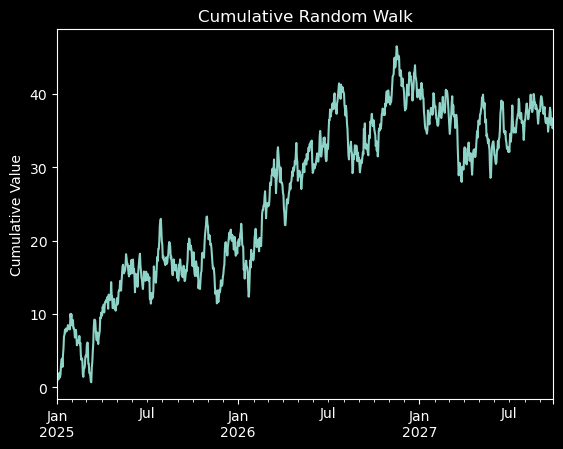

In [140]:
# Random walk time series
ts = pd.Series(np.random.randn(1000),
               index=pd.date_range('1/1/2025', periods=1000))

ts.cumsum().plot(kind="line", title="Cumulative Random Walk")
plt.ylabel("Cumulative Value")
plt.show()

### Working with Real Data — Earthquake Depth Over Time

Now let's apply line plotting to our earthquake data. We will plot **earthquake depth over time**. This can help identify whether there are temporal patterns to deep vs. shallow seismic events.

We use `eq.plot()` with `x='time'` and `y='depth'` to generate the line plot directly from the DataFrame.

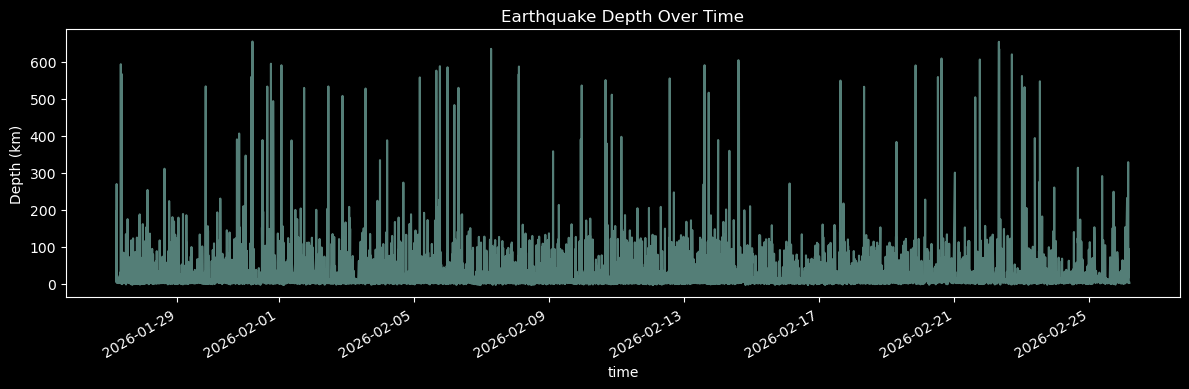

In [141]:
# Line plot of earthquake depth over time
eq_sorted = eq.sort_values('time')

eq_sorted.plot(x='time', y='depth', kind='line', figsize=(12, 4),
               title='Earthquake Depth Over Time', legend=False, alpha=0.6)
plt.ylabel("Depth (km)")
plt.tight_layout()
plt.show()

### Scatter Plot from a pandas DataFrame

Scatter plots from DataFrames are created using `kind='scatter'`. You must specify both `x` and `y` columns.

Let's create a scatter plot of earthquake **depth vs. magnitude**. Is there a relationship between how deep an earthquake occurs and how strong it is?

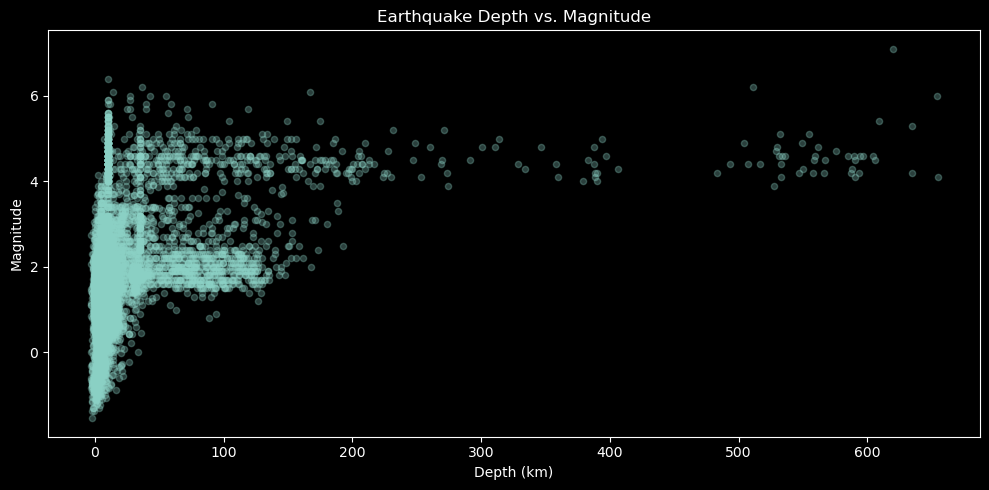

In [142]:
# Scatter plot: earthquake depth vs magnitude
eq.plot(kind='scatter',
        x='depth',
        y='mag',
        alpha=0.3,
        figsize=(10, 5),
        title='Earthquake Depth vs. Magnitude')
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.tight_layout()
plt.show()

### Bar Plot from a pandas DataFrame

Let's use the earthquake data to create a bar chart showing the **number of earthquakes per magnitude bin**. We will round each magnitude to the nearest integer to create categories, then count how many quakes fall in each group.

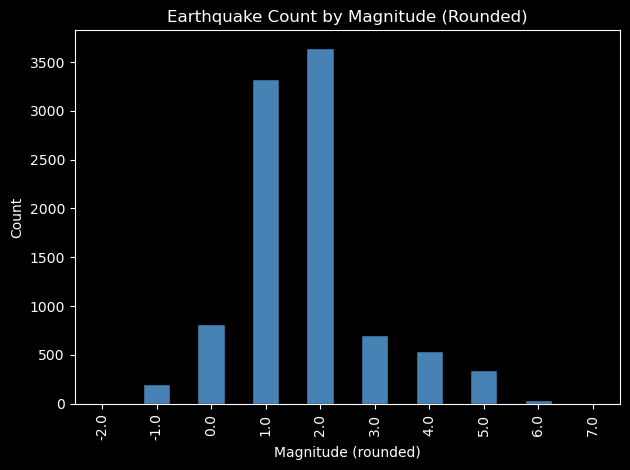

In [143]:
# Bar chart: earthquake counts per rounded magnitude
eq['mag_rounded'] = eq['mag'].round(0)
mag_counts = eq.groupby('mag_rounded').size()

mag_counts.plot(kind='bar', color='steelblue', edgecolor='black',
                title='Earthquake Count by Magnitude (Rounded)')
plt.xlabel("Magnitude (rounded)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Histogram from a pandas DataFrame

The `.plot.hist()` method creates a histogram directly from a DataFrame column. Let's compare two histograms:

1. Earthquake **magnitudes**
2. Earthquake **depths**

We will also experiment with different numbers of `bins` to see how the level of detail changes.

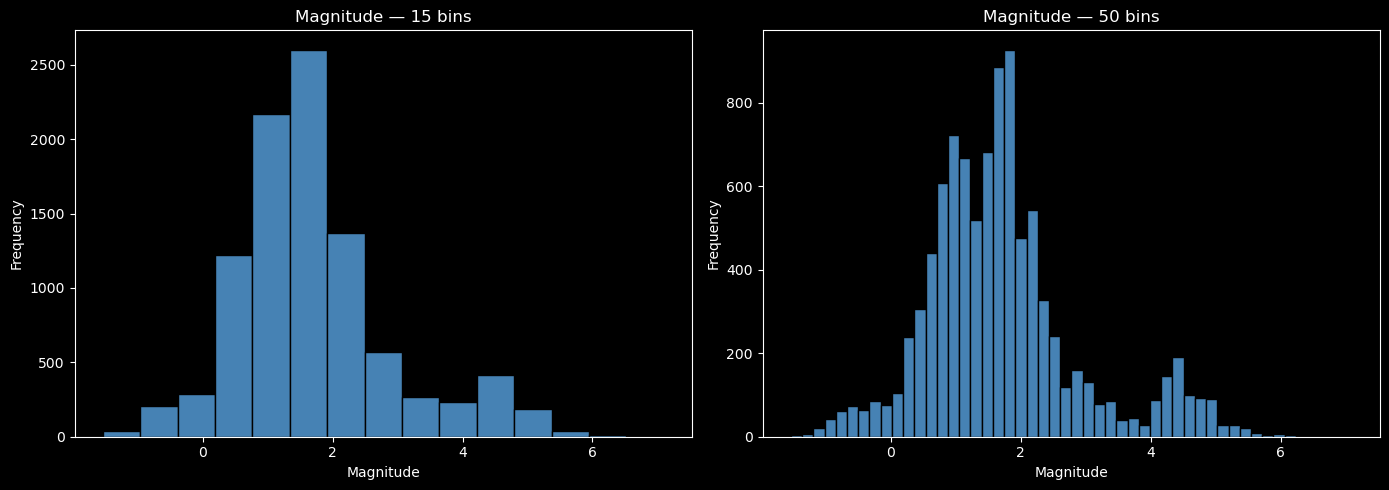

In [144]:
# Histogram of earthquake magnitudes with different bin counts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

eq['mag'].plot.hist(ax=ax1, bins=15, edgecolor='black', color='steelblue')
ax1.set_title("Magnitude — 15 bins")
ax1.set_xlabel("Magnitude")

eq['mag'].plot.hist(ax=ax2, bins=50, edgecolor='black', color='steelblue')
ax2.set_title("Magnitude — 50 bins")
ax2.set_xlabel("Magnitude")

plt.tight_layout()
plt.show()

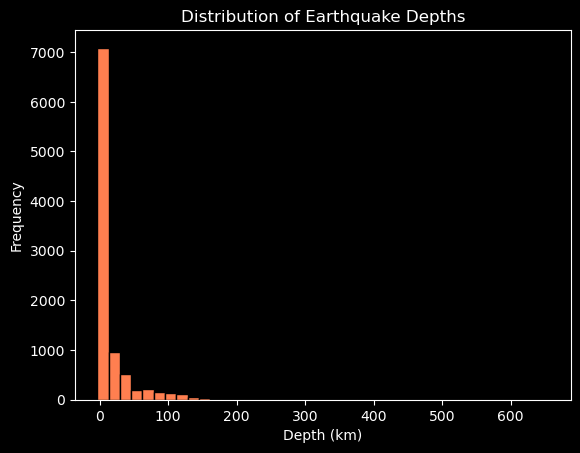

In [145]:
# Histogram of earthquake depths
eq['depth'].plot.hist(bins=40, edgecolor='black', color='coral',
                      title='Distribution of Earthquake Depths')
plt.xlabel("Depth (km)")
plt.show()

### Plotting Multiple Columns with `subplots=True`

If your DataFrame has several numeric columns, you can create a histogram for **each column at once** by passing `subplots=True` to the `.plot.hist()` method. This is a quick way to get an overview of all your numeric variables.

Below we select just the key numeric columns from the earthquake dataset and let pandas generate one histogram per column.

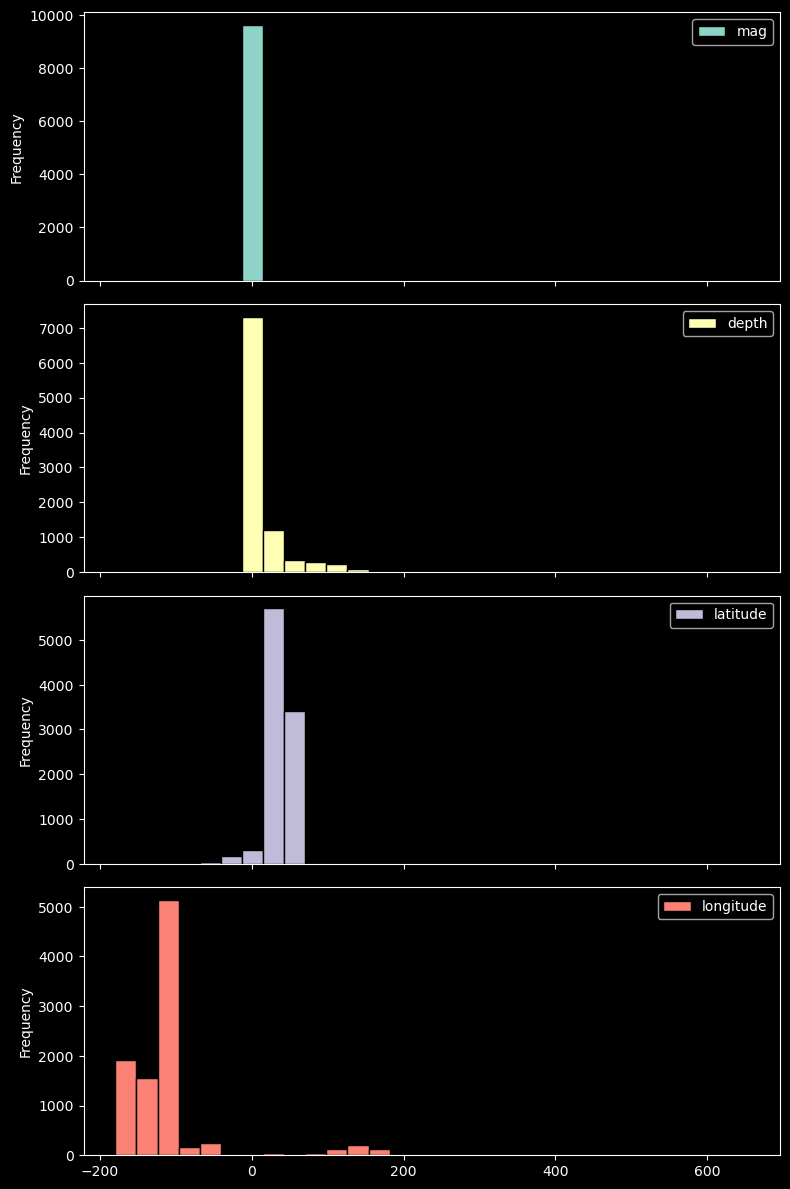

In [146]:
# Multi-column histograms
eq[['mag', 'depth', 'latitude', 'longitude']].plot.hist(
    subplots=True,
    figsize=(8, 12),
    bins=30,
    edgecolor='black',
    layout=(4, 1))

plt.tight_layout()
plt.show()

## Advanced Plots with pandas and the OO Interface

Now let's combine the power of **pandas DataFrames** with the **object‑oriented interface** to create richer, more customizable visualizations.

The key technique is to create a Figure and Axes first with `plt.subplots()`, then pass the `ax` object to the pandas `.plot()` method:

```python
fig, ax = plt.subplots(figsize=(10, 6))
df.plot(kind='scatter', x='col_a', y='col_b', ax=ax)
ax.set_title('My Custom Title')
```

This lets you add custom legends, reference lines, annotations, and more.

### Analyzing Earthquake Depth by Magnitude

Let's explore the relationship between earthquake depth and magnitude in more detail. We will filter to earthquakes with magnitude ≥ 2.5 (the approximate threshold for human perception) and color the points by depth.

In [147]:
# Filter to significant earthquakes (mag >= 2.5)
sig_eq = eq[eq['mag'] >= 2.5].copy()
print(f"Significant earthquakes (mag >= 2.5): {len(sig_eq):,}")
sig_eq.head()

Significant earthquakes (mag >= 2.5): 1,721


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,mag_rounded
9619,2026-01-27 04:56:36.270000+00:00,-20.4303,-176.9126,269.516,4.5,mb,73,98,5.282,0.73,...,"186 km WNW of Houma, Tonga",earthquake,10.88,7.818,0.068,64.0,reviewed,us,us,4.0
9615,2026-01-27 05:08:06.319000+00:00,-15.0371,-174.7346,198.528,4.1,mb,31,112,3.072,0.61,...,"142 km NW of Hihifo, Tonga",earthquake,9.93,8.055,0.120,23.0,reviewed,us,us,4.0
9601,2026-01-27 06:15:33.294000+00:00,-7.9312,110.4559,10.000,4.6,mb,32,71,0.876,0.79,...,"12 km E of Pundong, Indonesia",earthquake,4.67,1.882,0.114,23.0,reviewed,us,us,5.0
9594,2026-01-27 07:00:18.582000+00:00,13.0892,-91.0715,10.000,4.0,mb,27,187,1.494,1.38,...,"96 km SSW of Puerto San José, Guatemala",earthquake,8.44,1.974,0.139,16.0,reviewed,us,us,4.0
9584,2026-01-27 07:54:38.733000+00:00,-23.5235,178.9088,593.252,4.2,mb,50,87,5.805,0.75,...,south of the Fiji Islands,earthquake,13.94,7.827,0.062,72.0,reviewed,us,us,4.0


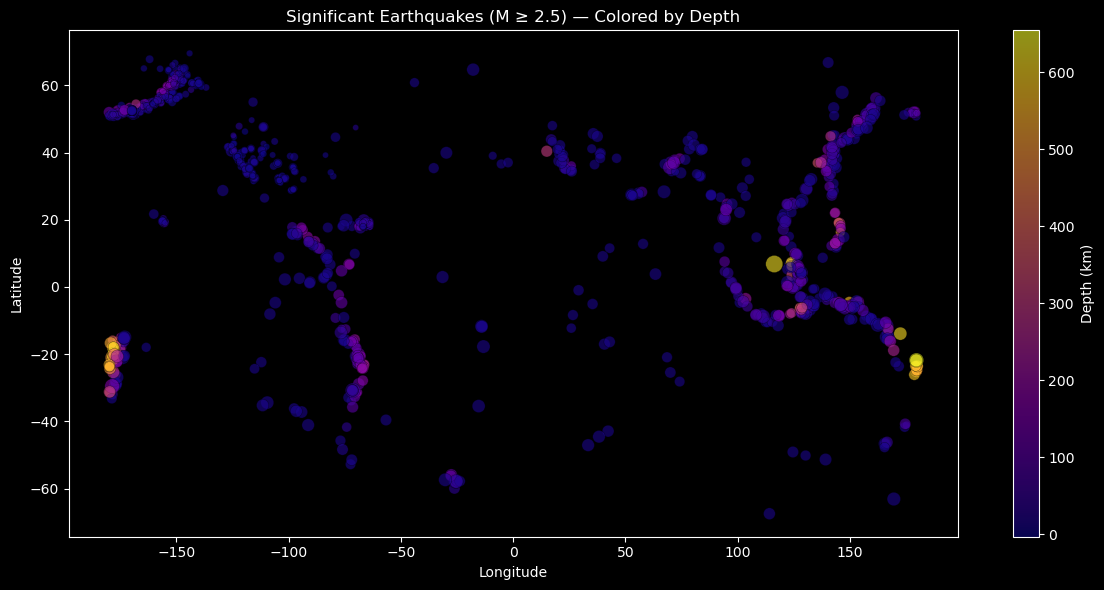

In [148]:
# Scatter plot colored by depth
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(sig_eq['longitude'], sig_eq['latitude'],
                     c=sig_eq['depth'],
                     cmap='plasma',
                     s=sig_eq['mag'] ** 2 * 3,
                     alpha=0.6,
                     edgecolors='black',
                     linewidths=0.3)

ax.set_title("Significant Earthquakes (M ≥ 2.5) — Colored by Depth")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(scatter, ax=ax, label="Depth (km)")
plt.tight_layout()
plt.show()

### Adding Reference Lines

Reference lines help the viewer contextualize the data. For example, we can add a **horizontal line** at the median depth to show how individual earthquakes compare to the overall trend.

- `ax.axhline()` draws a horizontal line across the entire width of the Axes.
- `ax.axvline()` draws a vertical line across the entire height.

Both accept parameters for `color`, `linestyle`, `linewidth`, and `label` (for the legend).

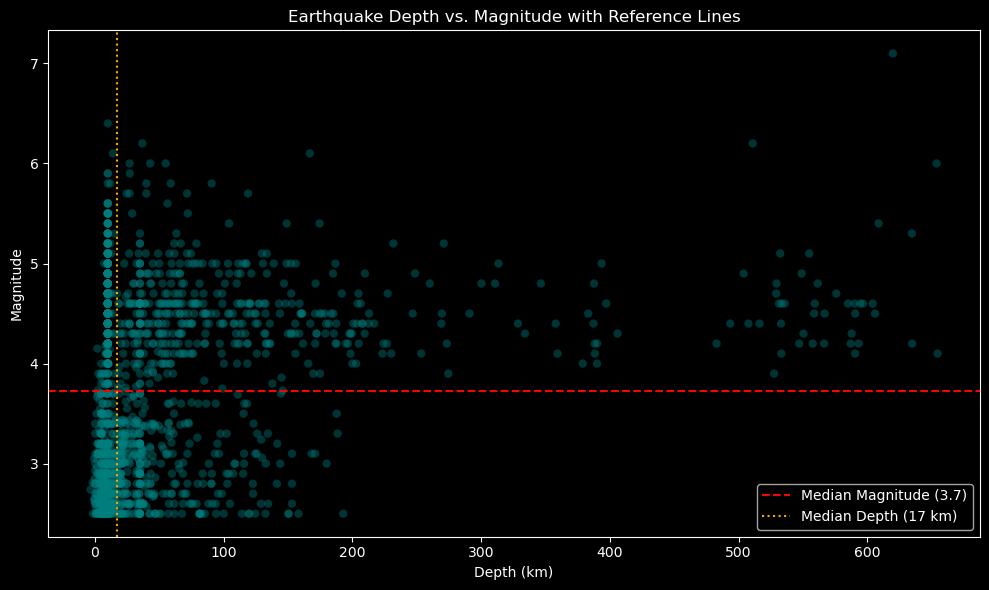

In [149]:
# Scatter with a reference line at median magnitude
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(sig_eq['depth'], sig_eq['mag'], alpha=0.4, c='teal', edgecolors='none')

# Add reference lines
median_mag = sig_eq['mag'].median()
median_depth = sig_eq['depth'].median()

ax.axhline(y=median_mag, color='red', linestyle='--', linewidth=1.5,
           label=f'Median Magnitude ({median_mag:.1f})')
ax.axvline(x=median_depth, color='orange', linestyle=':', linewidth=1.5,
           label=f'Median Depth ({median_depth:.0f} km)')

ax.set_title("Earthquake Depth vs. Magnitude with Reference Lines")
ax.set_xlabel("Depth (km)")
ax.set_ylabel("Magnitude")
ax.legend()
plt.tight_layout()
plt.show()

### Multi‑Panel Figure — Earthquake and Hurricane Analysis

Let's put everything together into a polished two‑panel figure that combines data from **both** datasets.

- **Top panel:** Earthquake locations colored by magnitude.
- **Bottom panel:** Hurricane wind speed over time for a selected storm.

We use `plt.subplots(nrows=2, ncols=1)` and then decorate each Axes individually.

C:\Users\georg\AppData\Local\ESRI\conda\envs\arcgispro-py3-dl\Lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
C:\Users\georg\AppData\Local\ESRI\conda\envs\arcgispro-py3-dl\Lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


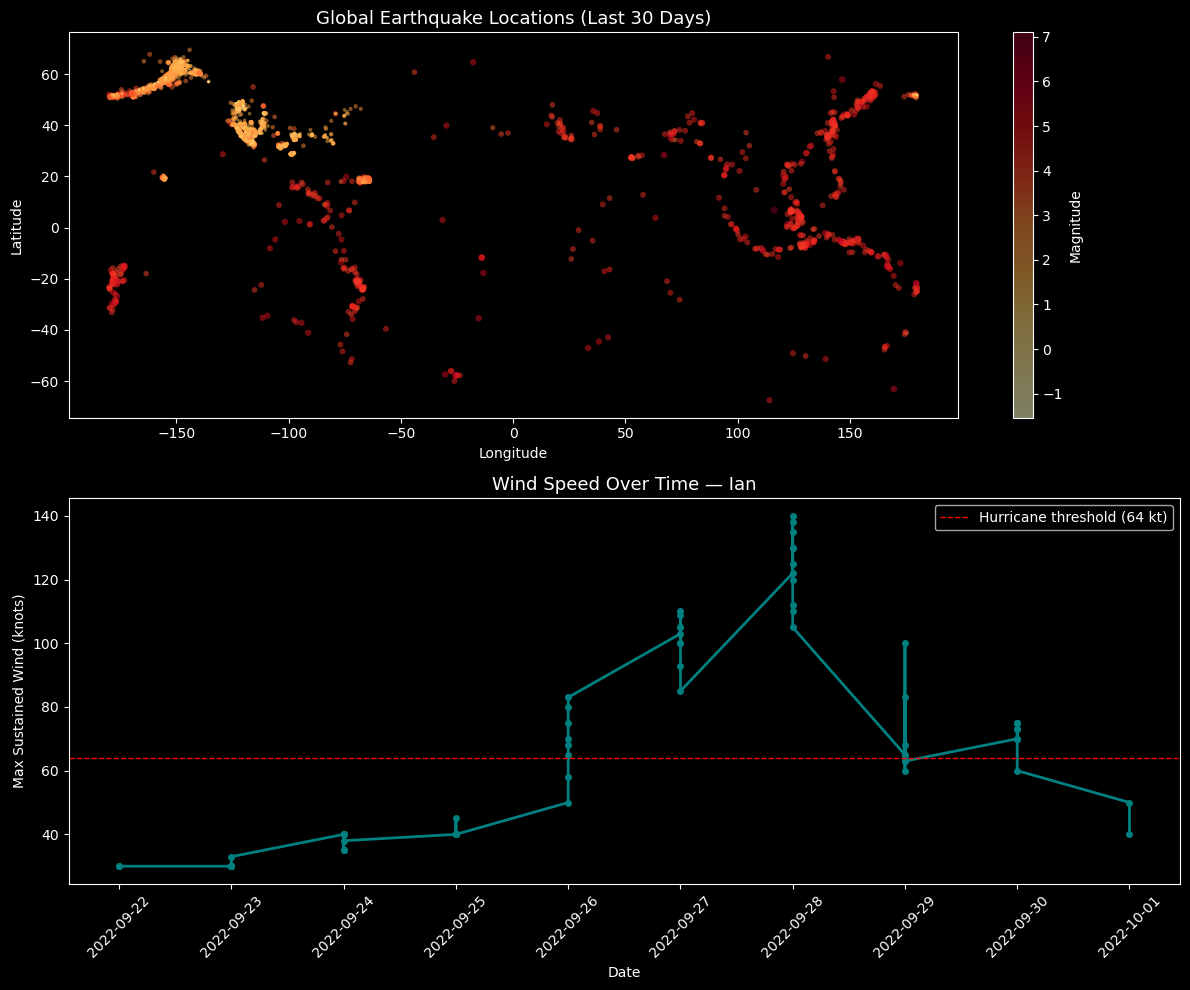

In [150]:
# Multi-panel figure combining both datasets
fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# ---------- Top: Earthquake scatter ----------
scatter = ax0.scatter(eq['longitude'], eq['latitude'],
                      c=eq['mag'], cmap='YlOrRd',
                      s=eq['mag'] * 4, alpha=0.5, edgecolors='none')
ax0.set_title("Global Earthquake Locations (Last 30 Days)", fontsize=13)
ax0.set_xlabel("Longitude")
ax0.set_ylabel("Latitude")
plt.colorbar(scatter, ax=ax0, label="Magnitude")

# ---------- Bottom: Hurricane wind speed ----------
hur_dt = hur.copy()
hur_dt['date'] = pd.to_datetime(hur_dt[['year', 'month', 'day']])

# Pick a well-known storm if available, otherwise use the first
preferred = ['Ian', 'Fiona', 'Nicole']
available = [s for s in preferred if s in hur_dt['NAME'].values]
chosen = available[0] if available else hur_dt['NAME'].iloc[0]

storm = hur_dt[hur_dt['NAME'] == chosen].sort_values('date')

ax1.plot(storm['date'], storm['USA_WIND'], color='teal', linewidth=2, marker='o', markersize=4)
ax1.axhline(y=64, color='red', linestyle='--', linewidth=1, label='Hurricane threshold (64 kt)')
ax1.set_title(f"Wind Speed Over Time — {chosen}", fontsize=13)
ax1.set_xlabel("Date")
ax1.set_ylabel("Max Sustained Wind (knots)")
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Customizing Your Plots

Up to this point we have focused on getting data onto a plot. Now let's make those plots look **professional and publication‑ready**.

Matplotlib offers a huge range of customization options. In this section we will cover the most important ones:

1. **Styles** — Pre‑built themes that change the overall look of every plot.
2. **Titles, labels, and legends** — Communicating what the plot shows.
3. **Colormaps (`cmap`)** — Choosing effective color schemes.
4. **Axis limits (`xlim`, `ylim`)** — Focusing on a region of interest.

A well‑customized plot should tell its story without requiring the reader to guess what they are looking at.

### Styles

Matplotlib ships with many built‑in **style sheets** that change fonts, colors, gridlines, and backgrounds all at once. You apply a style with:

```python
plt.style.use('style_name')
```

Some popular styles include:

| Style | Description |
|---|---|
| `'default'` | The standard Matplotlib look |
| `'seaborn-v0_8-whitegrid'` | Clean white background with gridlines |
| `'fivethirtyeight'` | Bold colors inspired by the FiveThirtyEight blog |
| `'ggplot'` | Inspired by R's ggplot2 library |
| `'dark_background'` | White text/lines on a dark background |

You can list all available styles with `plt.style.available`. Let's try a few.

In [151]:
# List all available styles
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

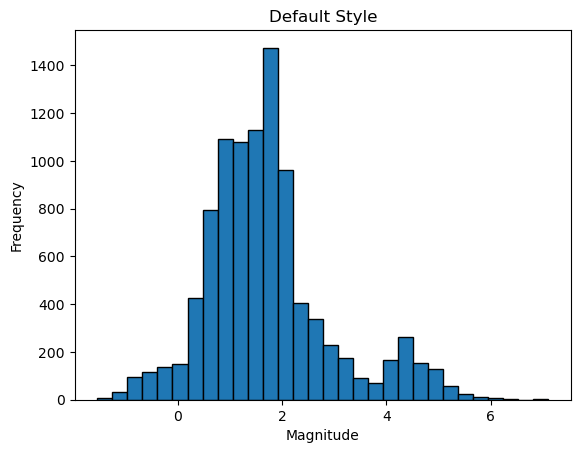

In [152]:
# Default style (reset first)
plt.style.use('default')

eq['mag'].dropna().plot.hist(bins=30, edgecolor='black', title='Default Style')
plt.xlabel('Magnitude')
plt.show()

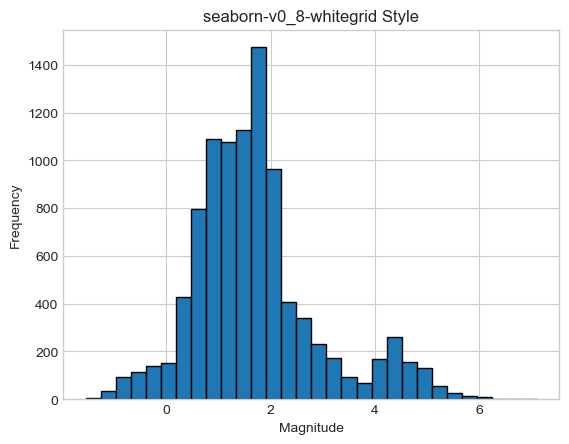

In [153]:
# Try seaborn whitegrid
plt.style.use('seaborn-v0_8-whitegrid')

eq['mag'].dropna().plot.hist(bins=30, edgecolor='black', title='seaborn-v0_8-whitegrid Style')
plt.xlabel('Magnitude')
plt.show()

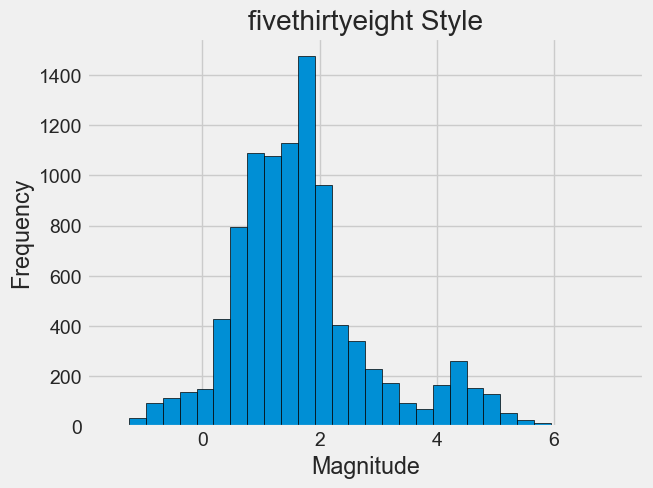

In [154]:
# Try fivethirtyeight
plt.style.use('fivethirtyeight')

eq['mag'].dropna().plot.hist(bins=30, edgecolor='black', title='fivethirtyeight Style')
plt.xlabel('Magnitude')
plt.show()

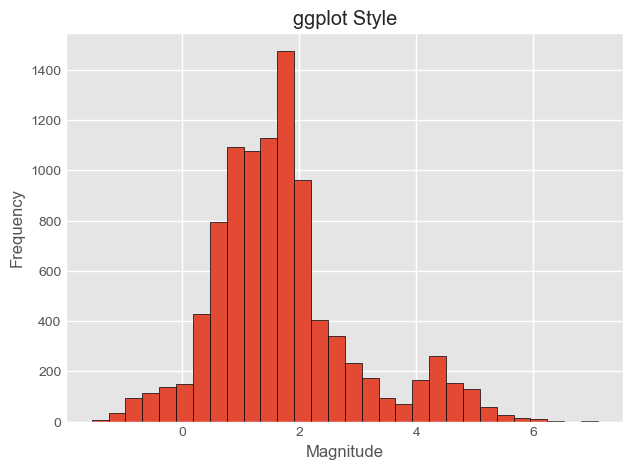

In [155]:
# Try ggplot
plt.style.use('ggplot')

eq['mag'].dropna().plot.hist(bins=30, edgecolor='black', title='ggplot Style')
plt.xlabel('Magnitude')
plt.show()

In [156]:
# Reset back to default for the rest of the notebook
plt.style.use('default')

### Titles, Labels, and Legends

Every plot should have, at minimum:

- A **title** that describes what the plot shows.
- **Axis labels** that identify what each axis represents, including units.
- A **legend** if there are multiple data series on the same plot.

With the OO interface, all of these can be set in a single call using `ax.set()`:

```python
ax.set(title='My Plot',
       xlabel='X Variable (units)',
       ylabel='Y Variable (units)')
```

Legends are controlled with `ax.legend()`. The `loc` parameter lets you position the legend — common options include `'upper right'`, `'lower left'`, and `'best'` (the default, which lets Matplotlib choose).

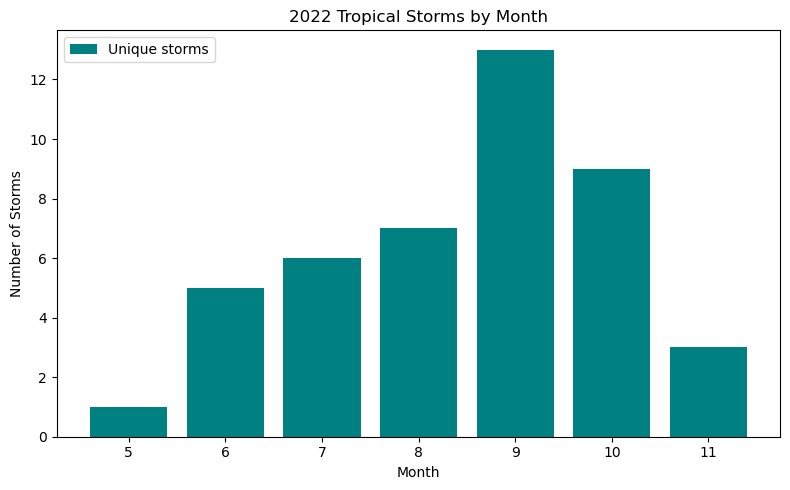

In [157]:
# Demonstrate title, labels, and legend placement
storms_per_month = hur.groupby('month')['SID'].nunique()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(storms_per_month.index, storms_per_month.values,
       color='teal', label='Unique storms')

ax.set(title='2022 Tropical Storms by Month',
       xlabel='Month',
       ylabel='Number of Storms')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Colormaps (`cmap`)

When you color data points by a continuous variable (like magnitude or depth), the **colormap** determines which colors represent low vs. high values.

Matplotlib has dozens of colormaps, organized into categories:

| Category | Good For | Examples |
|---|---|---|
| Sequential | Low‑to‑high values | `'viridis'`, `'plasma'`, `'YlOrRd'` |
| Diverging | Values with a meaningful center | `'coolwarm'`, `'RdBu'` |
| Qualitative | Distinct categories | `'Set1'`, `'tab10'` |

For spatial data, **sequential** colormaps are used most often (e.g., earthquake magnitude). **Diverging** colormaps are useful when data has a meaningful midpoint (e.g., temperature anomaly around zero).

The full colormap reference is available at: [matplotlib.org/stable/gallery/color/colormap_reference.html](https://matplotlib.org/stable/gallery/color/colormap_reference.html)

Let's compare two colormaps on the same earthquake scatter plot.

C:\Users\georg\AppData\Local\ESRI\conda\envs\arcgispro-py3-dl\Lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


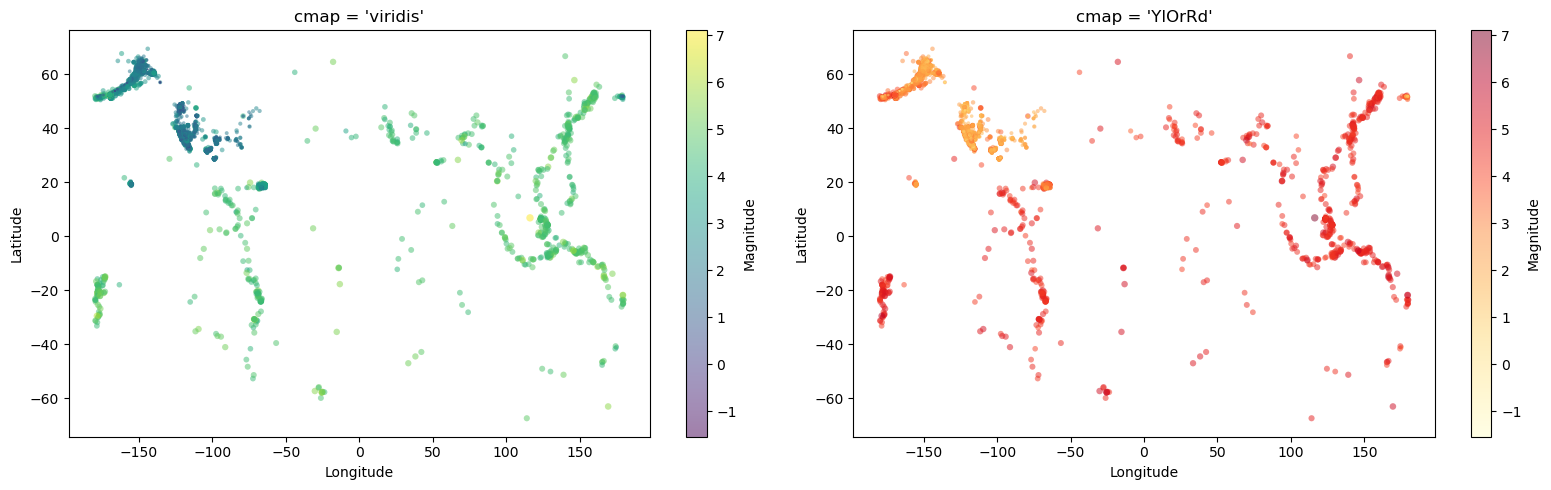

In [158]:
# Compare two colormaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, cmap_name in zip([ax1, ax2], ['viridis', 'YlOrRd']):
    sc = ax.scatter(eq['longitude'], eq['latitude'],
                    c=eq['mag'], cmap=cmap_name,
                    s=eq['mag'] * 4, alpha=0.5, edgecolors='none')
    ax.set_title(f"cmap = '{cmap_name}'")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, label='Magnitude')

plt.tight_layout()
plt.show()

### Axis Limits (`xlim` and `ylim`)

By default, Matplotlib automatically scales the axes to fit your data. However, you may want to **zoom in** on a specific region — for example, to focus on earthquakes near a particular tectonic boundary.

You can set custom axis ranges using:

```python
ax.set(xlim=[-180, -60], ylim=[10, 70])
```

Below we zoom our earthquake scatter plot to show only the **Americas**.

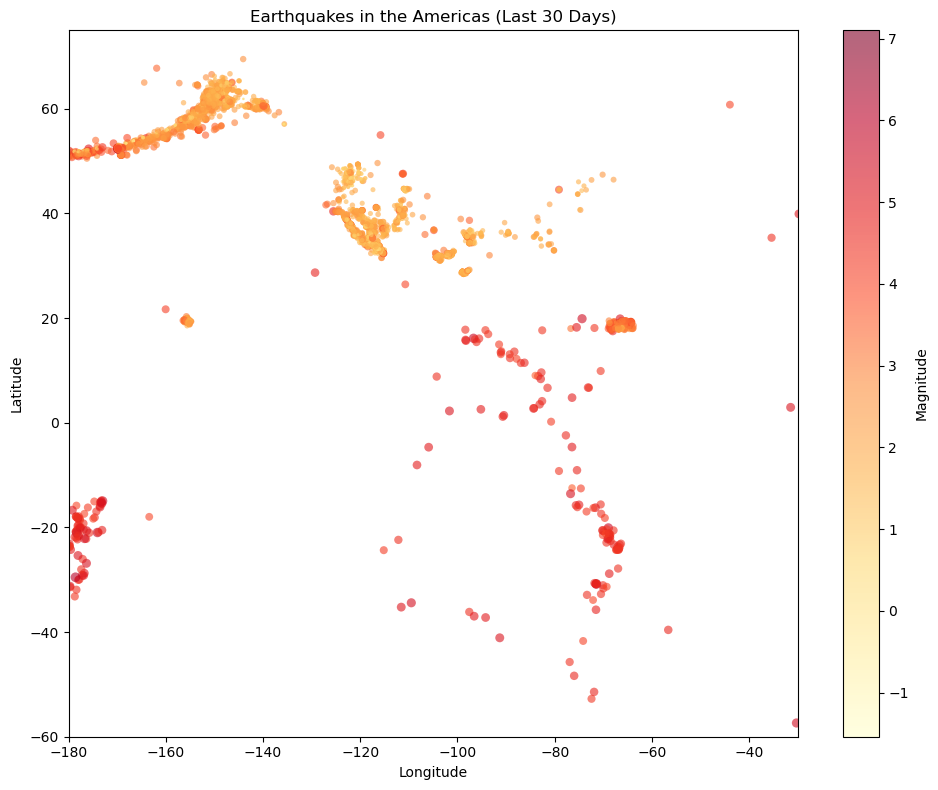

In [159]:
# Zoomed view: Americas only
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(eq['longitude'], eq['latitude'],
                     c=eq['mag'], cmap='YlOrRd',
                     s=eq['mag'] * 8, alpha=0.6, edgecolors='none')

ax.set(title='Earthquakes in the Americas (Last 30 Days)',
       xlabel='Longitude',
       ylabel='Latitude',
       xlim=[-180, -30],
       ylim=[-60, 75])

plt.colorbar(scatter, ax=ax, label='Magnitude')
plt.tight_layout()
plt.show()

## Saving Plots

Once you are happy with a figure, you will want to save it to a file so you can include it in a report, presentation, or publication.

Use the `fig.savefig()` method:

```python
fig.savefig('my_plot.png', dpi=150, bbox_inches='tight')
```

Key parameters:

- **`fname`** — The filename (and path) to save to. The file extension determines the format (`.png`, `.jpg`, `.pdf`, `.svg`, etc.).
- **`dpi`** (dots per inch) — Controls the resolution. 100 is fine for screens; 300 is standard for print.
- **`bbox_inches='tight'`** — Removes extra whitespace around the plot.

You can check all supported file types with:

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

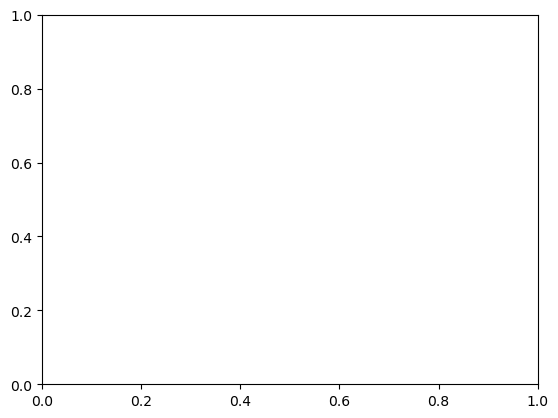

In [160]:
# Check supported file types
fig, ax = plt.subplots()  # need a figure to check
fig.canvas.get_supported_filetypes()

Now let's recreate our polished multi‑panel figure and save it.

C:\Users\georg\AppData\Local\ESRI\conda\envs\arcgispro-py3-dl\Lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Figure saved as 'spatial_analysis_figure.png'


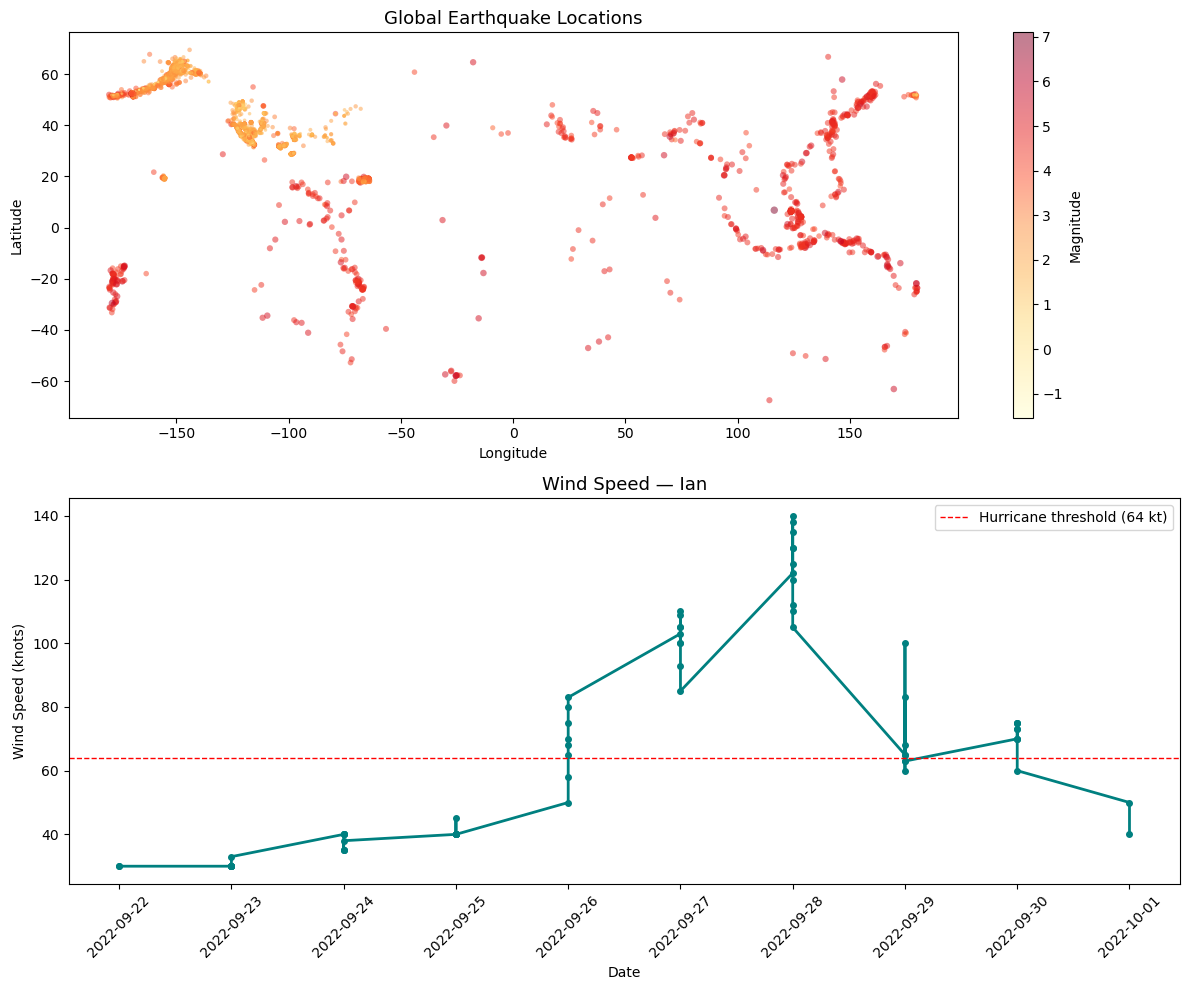

In [161]:
# Recreate the two-panel figure
fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Top: Earthquakes
sc = ax0.scatter(eq['longitude'], eq['latitude'],
                 c=eq['mag'], cmap='YlOrRd',
                 s=eq['mag'] * 4, alpha=0.5, edgecolors='none')
ax0.set_title("Global Earthquake Locations", fontsize=13)
ax0.set_xlabel("Longitude")
ax0.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax0, label="Magnitude")

# Bottom: Hurricane wind
hur_dt = hur.copy()
hur_dt['date'] = pd.to_datetime(hur_dt[['year', 'month', 'day']])
preferred = ['Ian', 'Fiona', 'Nicole']
available = [s for s in preferred if s in hur_dt['NAME'].values]
chosen = available[0] if available else hur_dt['NAME'].iloc[0]
storm = hur_dt[hur_dt['NAME'] == chosen].sort_values('date')

ax1.plot(storm['date'], storm['USA_WIND'], color='teal', linewidth=2, marker='o', markersize=4)
ax1.axhline(y=64, color='red', linestyle='--', linewidth=1, label='Hurricane threshold (64 kt)')
ax1.set_title(f"Wind Speed — {chosen}", fontsize=13)
ax1.set_xlabel("Date")
ax1.set_ylabel("Wind Speed (knots)")
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Save the figure
fig.savefig("spatial_analysis_figure.png", dpi=150, bbox_inches='tight')
print("Figure saved as 'spatial_analysis_figure.png'")

You can also save to PDF for inclusion in academic papers:

```python
fig.savefig('spatial_analysis_figure.pdf', bbox_inches='tight')
```

## Resetting Figures and Creating a Reusable Workflow Function

If you want to start a brand‑new figure after working on one for a while, simply create a new `fig, ax` pair. This "resets" your canvas:

```python
fig, ax = plt.subplots()
```

If you find yourself creating the same type of plot over and over again, it is a good idea to wrap the workflow into a **function**. Below is a template that follows the standard Matplotlib workflow.

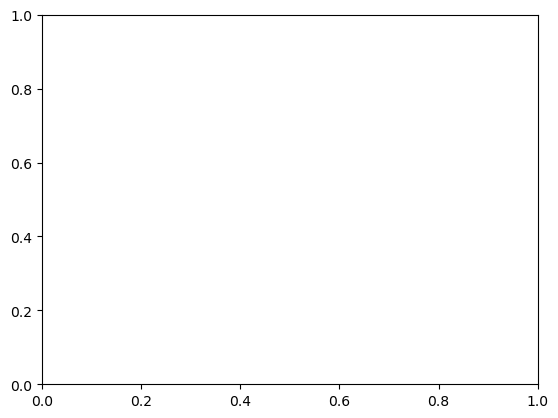

In [162]:
# Resets figure
fig, ax = plt.subplots()

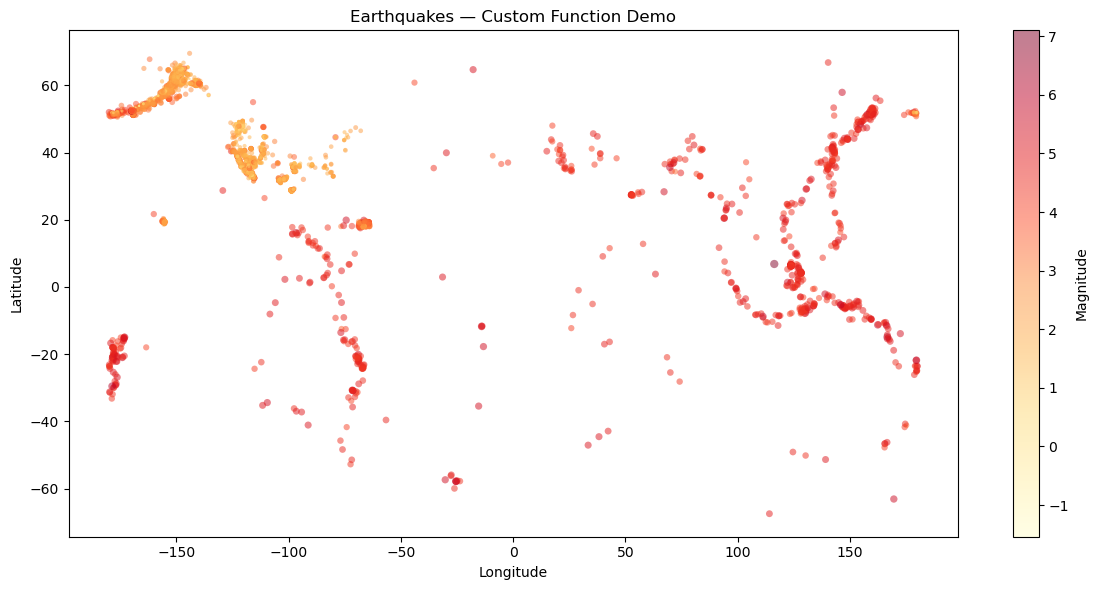

In [163]:
# Reusable plotting workflow function

def plot_earthquake_scatter(df, title="Earthquake Map", cmap="YlOrRd", figsize=(12, 6)):
    """Create a styled earthquake scatter plot.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'longitude', 'latitude', and 'mag' columns.
    title : str
        Plot title.
    cmap : str
        Matplotlib colormap name.
    figsize : tuple
        Figure dimensions (width, height).
    
    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    # 1. Setup
    fig, ax = plt.subplots(figsize=figsize)
    
    # 2. Plot
    sc = ax.scatter(df['longitude'], df['latitude'],
                    c=df['mag'], cmap=cmap,
                    s=df['mag'] * 5, alpha=0.5, edgecolors='none')
    
    # 3. Customize
    ax.set(title=title, xlabel='Longitude', ylabel='Latitude')
    plt.colorbar(sc, ax=ax, label='Magnitude')
    plt.tight_layout()
    
    return fig, ax

# Test the function
plot_earthquake_scatter(eq, title='Earthquakes — Custom Function Demo')
plt.show()

## Extra Resources

We have covered a lot of ground in this notebook, but we have really only scratched the surface of what Matplotlib can do. Here are some resources to help you continue learning:

- **[Matplotlib Quick Start Guide](https://matplotlib.org/stable/tutorials/introductory/quick_start.html)** — Try rewriting all the code in this guide to build muscle memory.
- **[Matplotlib Plot Types Gallery](https://matplotlib.org/stable/plot_types/index.html)** — Browse dozens of plot types to see what is possible.
- **[Lifecycle of a Plot](https://matplotlib.org/stable/tutorials/introductory/lifecycle.html)** — A detailed walkthrough of creating, customizing, and saving a plot from start to finish.
- **[Colormap Reference](https://matplotlib.org/stable/gallery/color/colormap_reference.html)** — All available colormaps with visual previews.
- **[Choosing Colormaps](https://matplotlib.org/stable/tutorials/colors/colormaps.html)** — Guidance on selecting effective colormaps for different types of data.

As you progress in GIS and spatial analysis, you will also want to explore **contextily** (for adding basemaps), **geopandas** `.plot()` (for plotting GeoDataFrames with geometries), and **folium** (for interactive web maps).